In [1]:
import geopandas as gpd
import earthaccess
from peatfire import data_path
import matplotlib.pyplot as plt
import rioxarray
import xarray as xr

In [ ]:
peat_restoration = gpd.read_file(
    data_path(
        'processed', 'peat_restoration',
        'NC_Pocosin_Restoration_Sites_2026',
        'NC_Pocosin_Restoration_Sites_2026.shp'
    )
)

nc = gpd.read_file(data_path('processed', 'boundaries', 'nc_boundary.gpkg'))

aoi_nc_peat_80_histosol = gpd.read_file(data_path("processed", "peat_extent", "nc_peatlands_80_histosol_aoi.gpkg"))

histosol = rioxarray.open_rasterio(data_path("processed", "peat_extent", "conus_histosol_major_percentage_nc.tif"), masked=True)

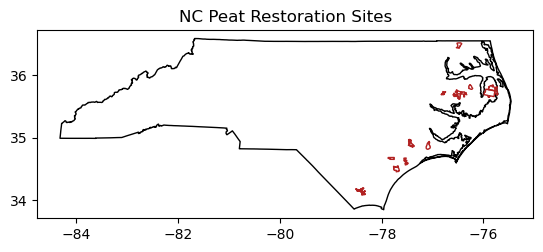

In [9]:
peat_restoration = peat_restoration.to_crs(nc.crs)
aoi_nc_peat_80_histosol = aoi_nc_peat_80_histosol.to_crs(nc.crs)
fig, ax = plt.subplots()

nc.plot(ax=ax, facecolor='none')
peat_restoration.plot(ax=ax, facecolor='none', edgecolor='firebrick', linewidth=1)
ax.set_title('NC Peat Restoration Sites')
fig.savefig('../outputs/figures/peat_restoration/nc_peat_restoration_sites.png')

In [ ]:
aoi_nc_peat_80_histosol_no_restoration = gpd.overlay(aoi_nc_peat_80_histosol, peat_restoration, how='difference')

Text(0.5, 1.0, 'test')

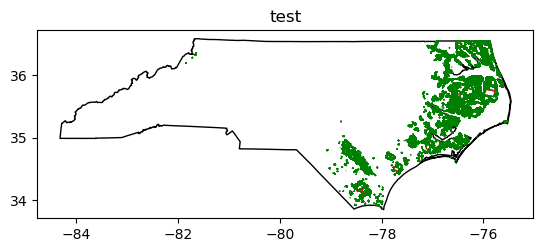

In [ ]:
fig, ax = plt.subplots()

nc.plot(ax=ax, facecolor='none')
peat_restoration.plot(ax=ax, facecolor='none', edgecolor='firebrick', linewidth=1)
aoi_nc_peat_80_histosol_no_restoration.plot(ax=ax, facecolor='none', edgecolor='green', linewidth=1)


In [ ]:
# clip 80% peat mask to drop the peat restoration polygons plus a buffer

# then grab nearest unrestored peat pixels to each restoration site as candidate controls
# then match on distance to coast, elevation, land cover, histosol % using nearest-neighbor via pymatch
# plot before and after matching